> **Originally created in August 2022** — before generative AI tools became widely available. This notebook was developed entirely through manual data analysis, feature engineering, and model tuning as the capstone project for the **13th term of [ITU SEM Data Science Specialization Certificate Program](https://itusem.itu.edu.tr/egitimler-ve-programlar/isletme-fakultesi-sertifika-programlari/data-science--uzmanligi-sertifika-programi)**.


# 1. It's a binary classification problem and the target variable is the "Transported".

variable descriptions:

PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.

HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.

CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.

Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.

Destination - The planet the passenger will be debarking to.

Age - The age of the passenger.

VIP - Whether the passenger has paid for special VIP service during the voyage.

RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many 
luxury amenities.

Name - The first and last names of the passenger.

Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

# 2. importing libraries and loading the data

In [134]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [135]:
#I got the data from a kaggle competition called Spaceship Titanic, I am going to use the "train.csv" data within it
ssdata = pd.read_csv("train.csv")
X = ssdata.drop("Transported", axis = 1)
y = ssdata["Transported"]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=.30,random_state =123)


# 3. data observation

In [136]:
print(X_train.shape)
X_train.head()

(6085, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
2743,2944_03,Earth,True,G/469/S,55 Cancri e,29.0,False,0.0,0.0,0.0,0.0,0.0,Sta Nichoan
5928,6290_01,Earth,False,G/1013/P,TRAPPIST-1e,36.0,False,78.0,9.0,0.0,0.0,841.0,Kentha Beangley
4794,5116_01,Mars,True,F/980/S,TRAPPIST-1e,25.0,False,0.0,0.0,0.0,0.0,0.0,Ars Prity
7057,7510_01,Mars,False,F/1435/S,55 Cancri e,18.0,False,1092.0,0.0,208.0,150.0,0.0,Pars Horte
7417,7935_01,Earth,False,F/1520/S,TRAPPIST-1e,41.0,False,84.0,0.0,6.0,811.0,2.0,Ward Rodger


In [137]:
print(X_train.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 6085 entries, 2743 to 3582
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   6085 non-null   object 
 1   HomePlanet    5941 non-null   object 
 2   CryoSleep     5937 non-null   object 
 3   Cabin         5939 non-null   object 
 4   Destination   5951 non-null   object 
 5   Age           5961 non-null   float64
 6   VIP           5944 non-null   object 
 7   RoomService   5954 non-null   float64
 8   FoodCourt     5947 non-null   float64
 9   ShoppingMall  5938 non-null   float64
 10  Spa           5961 non-null   float64
 11  VRDeck        5954 non-null   float64
 12  Name          5944 non-null   object 
dtypes: float64(6), object(7)
memory usage: 665.5+ KB
None


In [138]:
X_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,5961.000000,5954.000000,5947.000000,5938.000000,5961.000000,5954.000000
mean,28.757255,223.693147,469.283336,177.607949,314.723033,312.030232
std,14.456506,685.255778,1607.034489,631.313718,1155.539117,1170.221052
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,44.000000,87.000000,28.750000,70.000000,44.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,20336.000000


#### missing values


In [139]:
#checking for missing values

print("Missing value counts on the X_training set")
print(X_train.isna().sum().sort_values())


Missing value counts on the X_training set
PassengerId       0
Age             124
Spa             124
RoomService     131
VRDeck          131
Destination     134
FoodCourt       138
VIP             141
Name            141
HomePlanet      144
Cabin           146
ShoppingMall    147
CryoSleep       148
dtype: int64


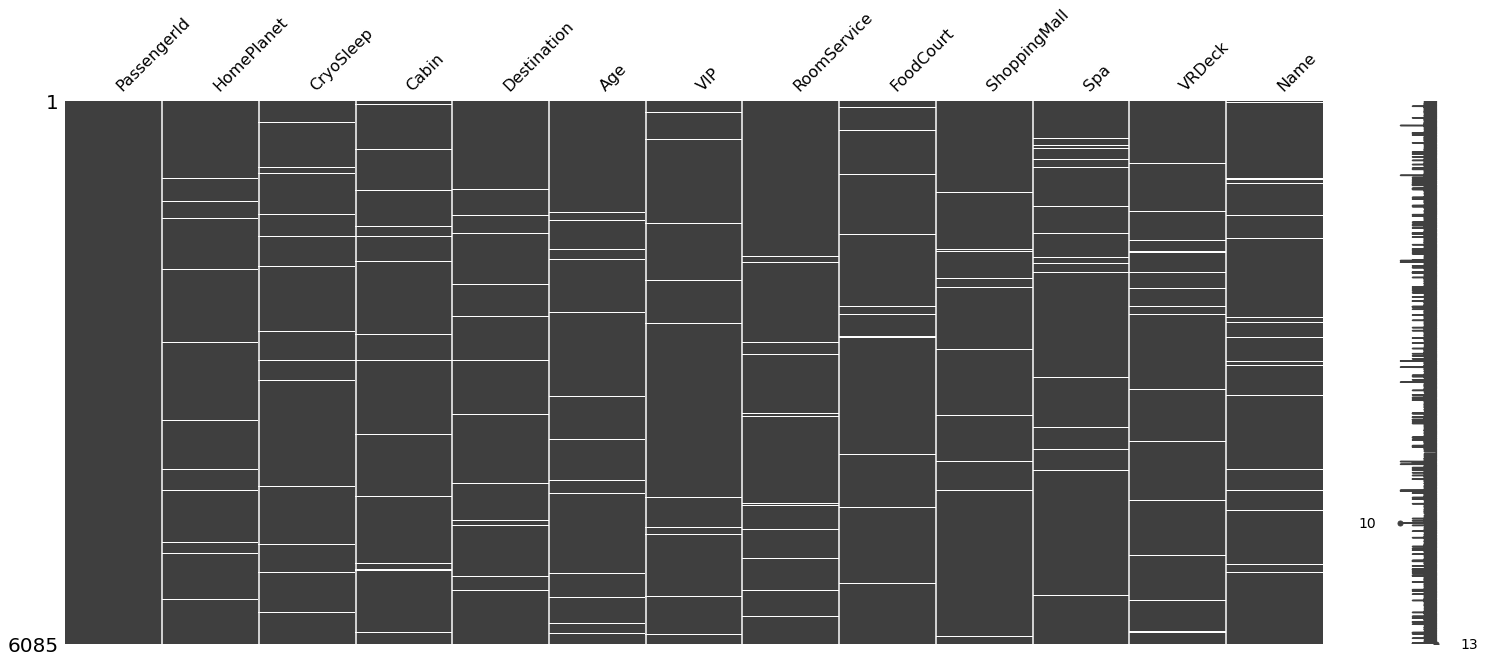

In [140]:
import missingno as msno
msno.matrix(X_train)

#we can see the missing value patterns on the data

In [141]:
 ##### we should handle this missing values later

#### correlation check

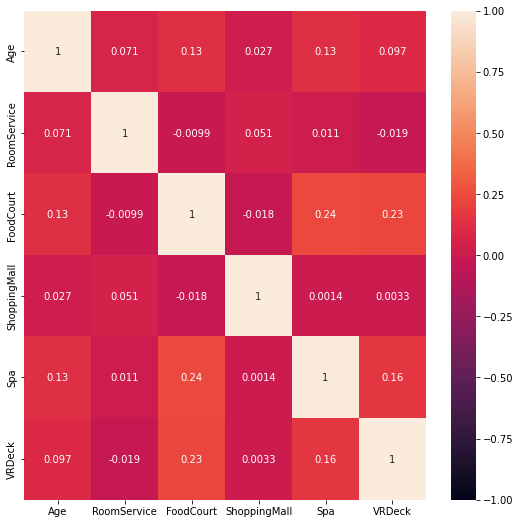

In [142]:
plt.figure(figsize=(9, 9))
heatmap = sns.heatmap(X_train.corr(), vmin=-1, vmax=1, annot=True,)


#### duplicate check

In [143]:
print(X_train.duplicated().sum())


0


In [144]:
# no duplicates in our data 

#### counting unique values

In [145]:
#number of unique values in each column, shows cardinality and gives a hint about the data types
X_train.nunique().sort_values(axis=0)

CryoSleep          2
VIP                2
HomePlanet         3
Destination        3
Age               80
ShoppingMall     902
RoomService     1014
VRDeck          1033
Spa             1068
FoodCourt       1210
Cabin           4875
Name            5934
PassengerId     6085
dtype: int64

In [146]:
# PassengerId, Cabin and Name variables show high cardinality. 
# CryoSleep, VIP, Transported, Homeplanet and Destination variables are categorical.
#Cryosleep, VIP, and Transported are boolean variables.


#### distribution of the target variable

In [147]:
y_train.value_counts()

True     3061
False    3024
Name: Transported, dtype: int64

In [148]:
# luckily, the target variable is balanced in distribution

### Distributions of Continuous features



#### age distribution

Text(0.5, 0, 'Age (years)')

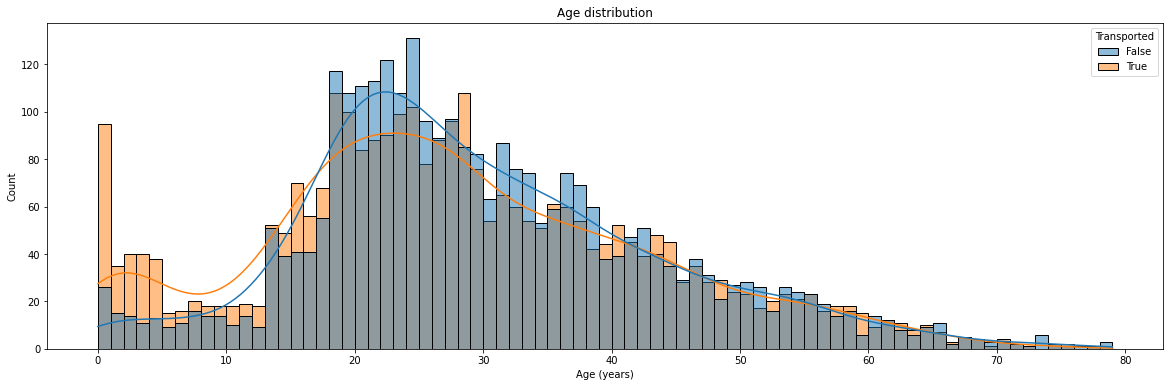

In [149]:
plt.figure(figsize=(20,6))
sns.histplot(data=X_train, x='Age', hue=y, binwidth=1, kde=True)
plt.title('Age distribution')
plt.xlabel('Age (years)')

In [150]:
#0 to around 18 seems to be more likely to be transported. then this trend is reversed until 40ies. 
#after age 40, the probability of being transported or not is nearly equal
#we should group and categorize them by considering this.


##### spending features distributions

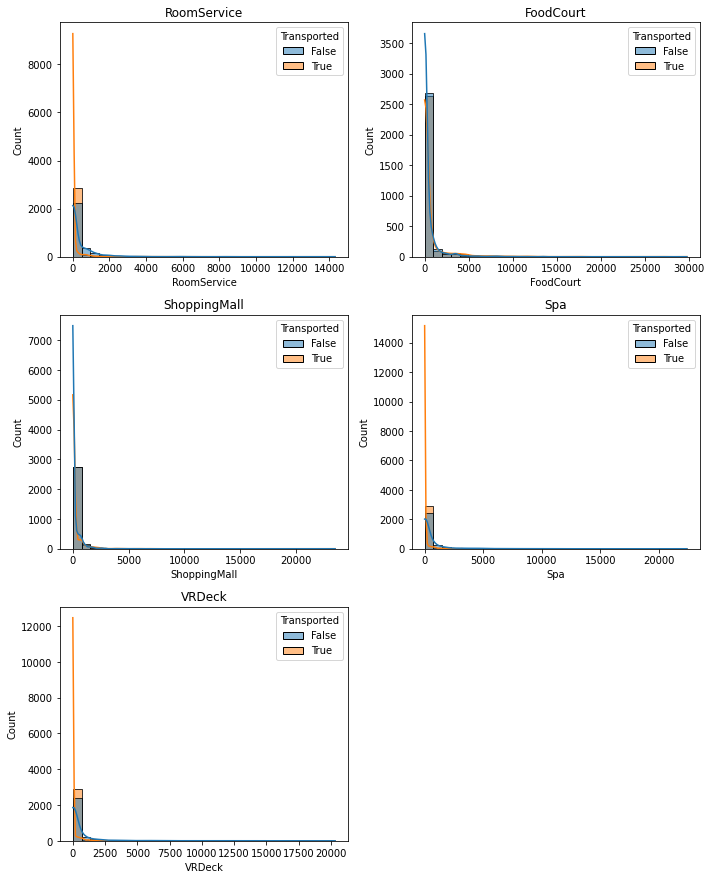

In [151]:
spendingfeatures=['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
fig=plt.figure(figsize=(10,20))
for i, var_name in enumerate(spendingfeatures):
    ax=fig.add_subplot(5,2,i+1)
    sns.histplot(data=X_train, x=var_name, axes=ax, bins=30, kde=True, hue=y)
    ax.set_title(var_name)
fig.tight_layout()
plt.show()


In [152]:
#it appears as that most of the people did not spend any money

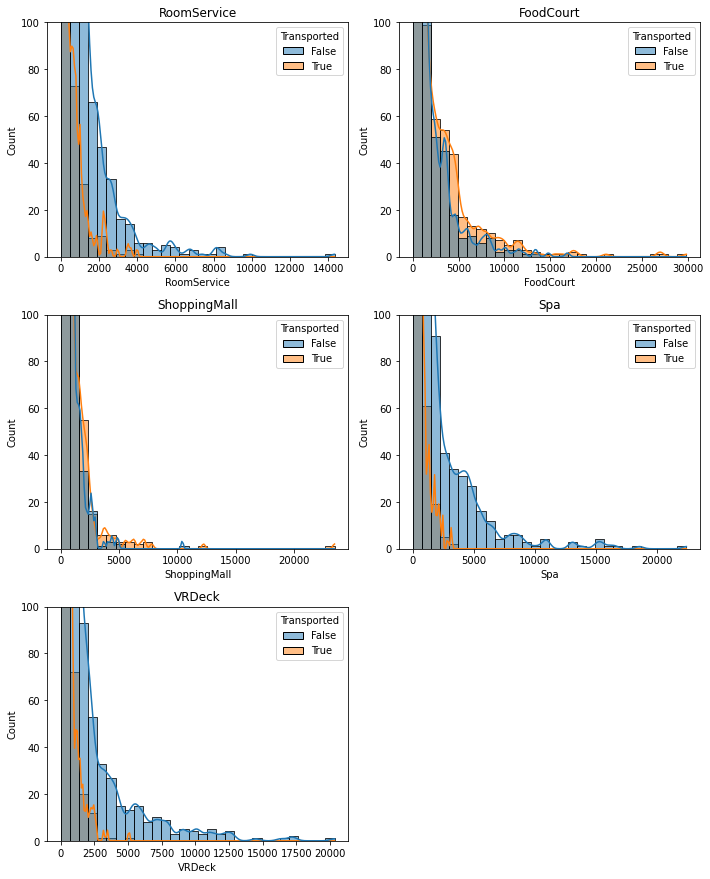

In [153]:
#we should look closer for further investigation 
fig=plt.figure(figsize=(10,20))
for i, var_name in enumerate(spendingfeatures):
    ax=fig.add_subplot(5,2,i+1)
    sns.histplot(data=X_train, x=var_name, axes=ax, bins=30, kde=True, hue=y)
    plt.ylim([0,100])
    ax.set_title(var_name)
fig.tight_layout()
plt.show()


In [154]:
#people who spend less were more likely to be transported.
#FoodCourt skewed to right compared to other, because food is more essential.

### Categorical features distributions

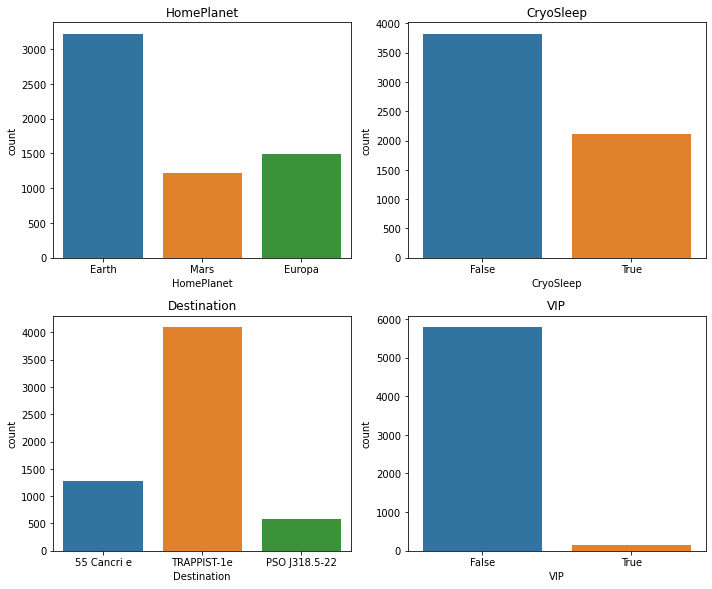

In [155]:
categorical=['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

# Plot categorical features
fig=plt.figure(figsize=(10,16))
for i, var_name in enumerate(categorical):
    ax=fig.add_subplot(4,2,i+1)
    sns.countplot(data=X_train, x=var_name, axes=ax)
    ax.set_title(var_name)
fig.tight_layout()  
plt.show()


In [156]:
#VIP is very unbalanced, we might consider dropping it
#CryoSleep seems to be a good one

# 4. Feature engineering

#### need to split some features

In [157]:
ssdata

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [158]:
def passengergroupseperator(data):
    #split the group number and the passenger number in the group
    data['PassengerGroup'] = data['PassengerId'].str.split('_', expand=True)[0]
    data['PassengerNumber']= data['PassengerId'].str.split('_', expand=True)[1]
    data.drop(columns = ['PassengerId'],  inplace = True)
    return data

X_train= passengergroupseperator(X_train)
X_test= passengergroupseperator(X_test)

In [159]:
def cabinseperator(data):
    #split cabin into deck, number and side
    data['CabDeck'] =data['Cabin'].str.split('/', expand=True)[0]
    data['CabNum']  = data['Cabin'].str.split('/', expand=True)[1]
    data['CabSide'] = data['Cabin'].str.split('/', expand=True)[2]
    data.drop(columns = ['Cabin'], inplace = True)
    return data

X_train= cabinseperator(X_train)
X_test= cabinseperator(X_test)

In [160]:
def nameseperator(data):
    #split the name column into name and surname
    data['Surname']  = data['Name'].str.split().str[1]
    data['Name'] = data['Name'].str.split().str[0]
    return data

X_train= nameseperator(X_train)
X_test= nameseperator(X_test)

In [161]:
def groupbyage(data):
    data['Agegroup']=np.nan
    data.loc[data['Age']<=17,'Agegroup']='0-17'
    data.loc[(data['Age']>17) & (data['Age']<=42),'Agegroup']='18-42'
    data.loc[(data['Age']>42),'Agegroup']='42+'
    data.drop(columns =['Age'], inplace= True)
    return data
X_train= groupbyage(X_train)
X_test= groupbyage(X_test)

In [162]:
X_train.head()

,HomePlanet,CryoSleep,Destination,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,PassengerGroup,PassengerNumber,CabDeck,CabNum,CabSide,Surname,Agegroup
2743,Earth,True,55 Cancri e,False,0.0,0.0,0.0,0.0,0.0,Sta,2944,03,G,469,S,Nichoan,18-42
5928,Earth,False,TRAPPIST-1e,False,78.0,9.0,0.0,0.0,841.0,Kentha,6290,01,G,1013,P,Beangley,18-42
4794,Mars,True,TRAPPIST-1e,False,0.0,0.0,0.0,0.0,0.0,Ars,5116,01,F,980,S,Prity,18-42
7057,Mars,False,55 Cancri e,False,1092.0,0.0,208.0,150.0,0.0,Pars,7510,01,F,1435,S,Horte,18-42
7417,Earth,False,TRAPPIST-1e,False,84.0,0.0,6.0,811.0,2.0,Ward,7935,01,F,1520,S,Rodger,18-42


In [163]:
X_test

,HomePlanet,CryoSleep,Destination,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,PassengerGroup,PassengerNumber,CabDeck,CabNum,CabSide,Surname,Agegroup
5734,Earth,NaN,TRAPPIST-1e,False,14.0,2.0,144.0,610.0,0.0,Therry,6076,01,G,988,S,Cames,18-42
8392,Europa,False,55 Cancri e,False,NaN,3751.0,0.0,5025.0,11741.0,Batomam,8970,01,C,300,P,Clugeammy,18-42
8120,Europa,False,55 Cancri e,False,1.0,764.0,1.0,265.0,1539.0,Avijava,8671,01,A,90,P,Ticagent,18-42
769,Mars,False,TRAPPIST-1e,False,1227.0,42.0,1.0,0.0,0.0,Crin,0809,02,F,151,S,Meake,NaN
5382,Earth,False,TRAPPIST-1e,False,0.0,625.0,0.0,0.0,356.0,Herina,5750,01,E,363,P,Parklaney,18-42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6777,Mars,False,TRAPPIST-1e,False,0.0,0.0,0.0,0.0,0.0,Mele,7156,04,E,475,S,Ramad,0-17
4414,Europa,False,TRAPPIST-1e,True,0.0,3119.0,0.0,1404.0,366.0,Stra,4689,01,C,182,S,Persoffly,18-42
2424,Mars,True,TRAPPIST-1e,False,0.0,0.0,0.0,0.0,0.0,Want,2597,01,F,500,S,Jamai,18-42
5934,Mars,True,TRAPPIST-1e,False,0.0,0.0,0.0,0.0,0.0,Risps,6300,01,F,1303,P,Pure,18-42


In [164]:
#now it looks more beautiful

In [165]:
#I would like to see the columns alphabetically sorted
X_train = X_train.reindex(sorted(X_train.columns), axis=1)
X_test = X_test.reindex(sorted(X_train.columns), axis=1)

In [166]:
X_train.head()

,Agegroup,CabDeck,CabNum,CabSide,CryoSleep,Destination,FoodCourt,HomePlanet,Name,PassengerGroup,PassengerNumber,RoomService,ShoppingMall,Spa,Surname,VIP,VRDeck
2743,18-42,G,469,S,True,55 Cancri e,0.0,Earth,Sta,2944,03,0.0,0.0,0.0,Nichoan,False,0.0
5928,18-42,G,1013,P,False,TRAPPIST-1e,9.0,Earth,Kentha,6290,01,78.0,0.0,0.0,Beangley,False,841.0
4794,18-42,F,980,S,True,TRAPPIST-1e,0.0,Mars,Ars,5116,01,0.0,0.0,0.0,Prity,False,0.0
7057,18-42,F,1435,S,False,55 Cancri e,0.0,Mars,Pars,7510,01,1092.0,208.0,150.0,Horte,False,0.0
7417,18-42,F,1520,S,False,TRAPPIST-1e,0.0,Earth,Ward,7935,01,84.0,6.0,811.0,Rodger,False,2.0


In [167]:
#now look at the data again, we suffer less cardinality
X_train.nunique().sort_values(axis=0)

CabSide               2
CryoSleep             2
VIP                   2
Agegroup              3
Destination           3
HomePlanet            3
CabDeck               8
PassengerNumber       8
ShoppingMall        902
RoomService        1014
VRDeck             1033
Spa                1068
FoodCourt          1210
CabNum             1679
Surname            2059
Name               2434
PassengerGroup     4701
dtype: int64

## filling missing values


In [168]:
#filling missing values on categorical values with mode and continous variables with mean:
LABELS = X_train.columns
for col in LABELS:
    if col in ['RoomService','FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
        X_train[col].fillna(X_train[col].mean(), inplace=True)
    else:
        X_train[col].fillna(X_train[col].mode()[0], inplace=True)

LABELS = X_test.columns
for col in LABELS:
    if col in ['RoomService','FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
        X_test[col].fillna(X_test[col].mean(), inplace=True)
    else:
        X_test[col].fillna(X_test[col].mode()[0], inplace=True)

        

In [169]:
print(X_train.isna().sum().sum())



0


#### missing values are handled

## drop unwanted columns


In [170]:
X_train.drop(columns = ['Name',"PassengerGroup","Surname","CabNum","VIP"],  inplace = True)

X_test.drop(columns = ['Name',"PassengerGroup","Surname","CabNum","VIP"],  inplace = True)


##  encoding

In [171]:
from sklearn.preprocessing import LabelEncoder

In [172]:
label_cols = ["HomePlanet", "CryoSleep","CabDeck","CabSide", "Destination" ,"Agegroup","PassengerNumber"]
def label_encoder(X_train,columns):
    for col in columns:
        X_train[col] = X_train[col].astype(str)
        X_train[col] = LabelEncoder().fit_transform(X_train[col])
        X_test[col]
    return X_train
ts = ["Transported"]
X_train= label_encoder(X_train ,label_cols)
X_test= label_encoder(X_test ,label_cols)

In [173]:
X_test

,Agegroup,CabDeck,CabSide,CryoSleep,Destination,FoodCourt,HomePlanet,PassengerNumber,RoomService,ShoppingMall,Spa,VRDeck
5734,1,6,1,0,2,2.0,0,0,14.000000,144.0,610.0,0.0
8392,1,2,0,0,0,3751.0,1,0,227.002346,0.0,5025.0,11741.0
8120,1,0,0,0,0,764.0,1,0,1.000000,1.0,265.0,1539.0
769,1,5,1,0,2,42.0,2,1,1227.000000,1.0,0.0,0.0
5382,1,4,0,0,2,625.0,0,0,0.000000,0.0,0.0,356.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6777,0,4,1,0,2,0.0,2,3,0.000000,0.0,0.0,0.0
4414,1,2,1,0,2,3119.0,1,0,0.000000,0.0,1404.0,366.0
2424,1,5,1,1,2,0.0,2,0,0.000000,0.0,0.0,0.0
5934,1,5,0,1,2,0.0,2,0,0.000000,0.0,0.0,0.0


# 5.Modeling

## we are using the Transported feature as output variable and the rest in the above table as input variables

In [174]:
#we are going to use RandomizedSearchCV for tuning hyperparameters, because it's more cpu friendly than gridsearchcv
#I set some ranges to search for tuning for all models and i applied cross validation to see if our model generalizes well.
#I tried not to tire my pc while setting them.


## RandomForestClassifier

In [175]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
RF = RandomForestClassifier(random_state=0)

RF_param = {'n_estimators': [20,50,100,150,200],
            'max_depth': np.arange(1,30),
            'max_features': np.arange(2,10),
            'min_samples_leaf': np.arange(1,20),
            'min_samples_split': np.arange(2,20),
            'criterion': ['gini', 'entropy']}

RF_cv = RandomizedSearchCV(RF, param_distributions=RF_param, cv=5, n_iter=20, random_state=0, verbose=3)
RF_cv.fit(X_train, y_train)
RF_cv.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END criterion=gini, max_depth=23, max_features=4, min_samples_leaf=15, min_samples_split=16, n_estimators=50;, score=0.797 total time=   0.2s
[CV 2/5] END criterion=gini, max_depth=23, max_features=4, min_samples_leaf=15, min_samples_split=16, n_estimators=50;, score=0.790 total time=   0.2s
[CV 3/5] END criterion=gini, max_depth=23, max_features=4, min_samples_leaf=15, min_samples_split=16, n_estimators=50;, score=0.787 total time=   0.2s
[CV 4/5] END criterion=gini, max_depth=23, max_features=4, min_samples_leaf=15, min_samples_split=16, n_estimators=50;, score=0.792 total time=   0.2s
[CV 5/5] END criterion=gini, max_depth=23, max_features=4, min_samples_leaf=15, min_samples_split=16, n_estimators=50;, score=0.799 total time=   0.2s
[CV 1/5] END criterion=entropy, max_depth=3, max_features=8, min_samples_leaf=17, min_samples_split=11, n_estimators=200;, score=0.771 total time=   1.6s
[CV 2/5] END criterion=entrop

{'n_estimators': 200,
 'min_samples_split': 8,
 'min_samples_leaf': 10,
 'max_features': 3,
 'max_depth': 16,
 'criterion': 'entropy'}

In [176]:
from sklearn.model_selection import cross_validate

RF_best = RandomForestClassifier(n_estimators=RF_cv.best_params_['n_estimators'], 
                                 max_features=RF_cv.best_params_['max_features'], 
                                 max_depth=RF_cv.best_params_['max_depth'], 
                                 criterion=RF_cv.best_params_['criterion'],
                                 min_samples_leaf=RF_cv.best_params_['min_samples_leaf'],
                                 min_samples_split=RF_cv.best_params_['min_samples_split'],
                                 random_state = 0)

RF_best.fit(X_train, y_train)

cv_scores = cross_validate(RF_best, X_train, y_train, scoring='accuracy', cv=5)
score_mean = round(cv_scores['test_score'].mean(), 5)
score_std = round(cv_scores['test_score'].std(), 5)
print(f'Mean accuracy of the RandomForestClassifier model by applied cv : {score_mean} \nStd : ({score_std})')

Mean accuracy of the RandomForestClassifier model by applied cv : 0.79737 
Std : (0.00704)


In [177]:
# our model seems to be generalizing well, having std of 0.00704 on cv accuracy results

In [178]:
RF_best.score(X_train, y_train)-RF_best.score(X_test, y_test)


0.016861650644499404

In [179]:
#Our RandomForestClassifier model has only 0.016861650644499404 more accuracy on the training set than it has on the test set.
#Means we do not have overfitting problem here.


## GradientBoostingClassifier


In [180]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
gbc = GradientBoostingClassifier(random_state=0)

gbc_parameters = {'n_estimators': [20,50,100,150,200],
             'learning_rate': [0.001, 0.01, 0.1, 1],
             'subsample': np.arange(0.1, 1.1, 0.1),
             'criterion': ['friedman_mse', 'squared_error'],
             'min_samples_split': np.arange(2,20),
             'min_samples_leaf': np.arange(1,20),
             'max_depth': np.arange(1,30),
             'max_features': np.arange(2,10)
            }

gbc_cv = RandomizedSearchCV(gbc, param_distributions=gbc_parameters, cv=5, n_iter=20, random_state=0, verbose=3)
gbc_cv.fit(X_train, y_train)
gbc_cv.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END criterion=friedman_mse, learning_rate=0.1, max_depth=3, max_features=8, min_samples_leaf=17, min_samples_split=18, n_estimators=20, subsample=0.5;, score=0.787 total time=   0.1s
[CV 2/5] END criterion=friedman_mse, learning_rate=0.1, max_depth=3, max_features=8, min_samples_leaf=17, min_samples_split=18, n_estimators=20, subsample=0.5;, score=0.781 total time=   0.1s
[CV 3/5] END criterion=friedman_mse, learning_rate=0.1, max_depth=3, max_features=8, min_samples_leaf=17, min_samples_split=18, n_estimators=20, subsample=0.5;, score=0.774 total time=   0.1s
[CV 4/5] END criterion=friedman_mse, learning_rate=0.1, max_depth=3, max_features=8, min_samples_leaf=17, min_samples_split=18, n_estimators=20, subsample=0.5;, score=0.784 total time=   0.1s
[CV 5/5] END criterion=friedman_mse, learning_rate=0.1, max_depth=3, max_features=8, min_samples_leaf=17, min_samples_split=18, n_estimators=20, subsample=0.5;, score=0.7

{'subsample': 1.0,
 'n_estimators': 50,
 'min_samples_split': 8,
 'min_samples_leaf': 19,
 'max_features': 7,
 'max_depth': 9,
 'learning_rate': 0.1,
 'criterion': 'squared_error'}

In [181]:
gbc_best = GradientBoostingClassifier(n_estimators=gbc_cv.best_params_['n_estimators'], 
                                      #loss=gbc_cv.best_params_['loss'], 
                                      subsample=gbc_cv.best_params_['subsample'], 
                                      criterion=gbc_cv.best_params_['criterion'],
                                      learning_rate=gbc_cv.best_params_['learning_rate'],
                                      max_features=gbc_cv.best_params_['max_features'], 
                                      max_depth=gbc_cv.best_params_['max_depth'], 
                                      min_samples_leaf=gbc_cv.best_params_['min_samples_leaf'],
                                      min_samples_split=gbc_cv.best_params_['min_samples_split'],
                                      random_state=0)

gbc_best.fit(X_train, y_train)
cv_scores = cross_validate(gbc_best, X_train, y_train, scoring='accuracy', cv=5)
score_mean = round(cv_scores['test_score'].mean(), 5)
score_std = round(cv_scores['test_score'].std(), 5)
print(f'Mean accuracy of the GradientBoostingClassifier model by applied cv : {score_mean} \nStd : ({score_std})')

Mean accuracy of the GradientBoostingClassifier model by applied cv : 0.79721 
Std : (0.00967)


In [182]:
gbc_best.score(X_train, y_train)-gbc_best.score(X_test, y_test)

0.04304648865005467

In [183]:
#we may have a bit overfitting problem here

## KNeighborsClassifier


In [184]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
knn_parameters = {'n_neighbors': np.arange(1,300),
             'p': [1,2],
             'weights': ['uniform','distance'],
                  "leaf_size" : list(range(1,1000))}
knn_cv = RandomizedSearchCV(knn, param_distributions=knn_parameters , scoring='accuracy', cv=5, verbose=3)
knn_cv.fit(X_train, y_train)
knn_cv.best_params_


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END leaf_size=89, n_neighbors=84, p=1, weights=distance;, score=0.781 total time=   0.1s
[CV 2/5] END leaf_size=89, n_neighbors=84, p=1, weights=distance;, score=0.781 total time=   0.1s
[CV 3/5] END leaf_size=89, n_neighbors=84, p=1, weights=distance;, score=0.779 total time=   0.1s
[CV 4/5] END leaf_size=89, n_neighbors=84, p=1, weights=distance;, score=0.763 total time=   0.1s
[CV 5/5] END leaf_size=89, n_neighbors=84, p=1, weights=distance;, score=0.782 total time=   0.1s
[CV 1/5] END leaf_size=707, n_neighbors=9, p=1, weights=uniform;, score=0.774 total time=   0.1s
[CV 2/5] END leaf_size=707, n_neighbors=9, p=1, weights=uniform;, score=0.769 total time=   0.1s
[CV 3/5] END leaf_size=707, n_neighbors=9, p=1, weights=uniform;, score=0.774 total time=   0.1s
[CV 4/5] END leaf_size=707, n_neighbors=9, p=1, weights=uniform;, score=0.775 total time=   0.1s
[CV 5/5] END leaf_size=707, n_neighbors=9, p=1, weights=unifo

{'weights': 'distance', 'p': 2, 'n_neighbors': 266, 'leaf_size': 218}

In [185]:
knn_best = KNeighborsClassifier(n_neighbors=knn_cv.best_params_['n_neighbors'],
                                p=knn_cv.best_params_['p'],
                                weights=knn_cv.best_params_['weights'],
                               leaf_size= knn_cv.best_params_['leaf_size'])

knn_best.fit(X_train, y_train)
cv_scores = cross_validate(knn_best, X_train, y_train, scoring='accuracy', cv=5)
score_mean = round(cv_scores['test_score'].mean(), 5)
score_std = round(cv_scores['test_score'].std(), 5)
print(f'Mean accuracy of the KNeighborsClassifier model by applied cv : {score_mean} \nStd : ({score_std})')

Mean accuracy of the KNeighborsClassifier model by applied cv : 0.77962 
Std : (0.00539)


In [186]:
knn_best.score(X_train, y_train)-knn_best.score(X_test, y_test)

0.14674284547640526

In [187]:
#our model seems to have a serious overfitting problem here

## RandomForestClassifier confusion matrix

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


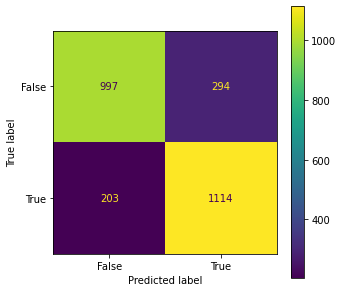

In [188]:
from sklearn.metrics import confusion_matrix, plot_confusion_matrix

fig, ax = plt.subplots(figsize=(5, 5))
plot_confusion_matrix(RF_best, X_test, y_test, ax=ax)  

## KNeighborsClassifier confusion matrix

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


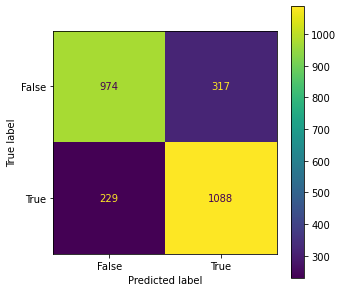

In [189]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_confusion_matrix(knn_best, X_test, y_test, ax=ax)  

## GradientBoostingClassifier confusion matrix

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


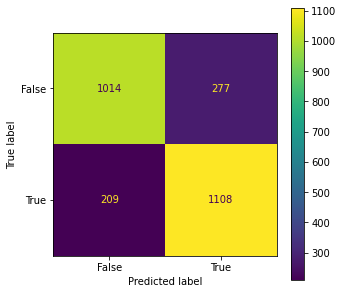

In [190]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_confusion_matrix(gbc_best, X_test, y_test, ax=ax)  

##Comparing the confusion matrixes, GradientBoostingClassifier predicts with more accuracy. Random forest is the second.

##All models gave nice scores on cross validation.

##KNN overfits. I would prefer running either GradientBoost or RandomForest on new data.

## While feature engineering and imputing missing values, we could use some assumptions using insight. It could give more accuracy to us on our models. I did not go for assumptions.